/tmp/ipykernel_588664/1793535690.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


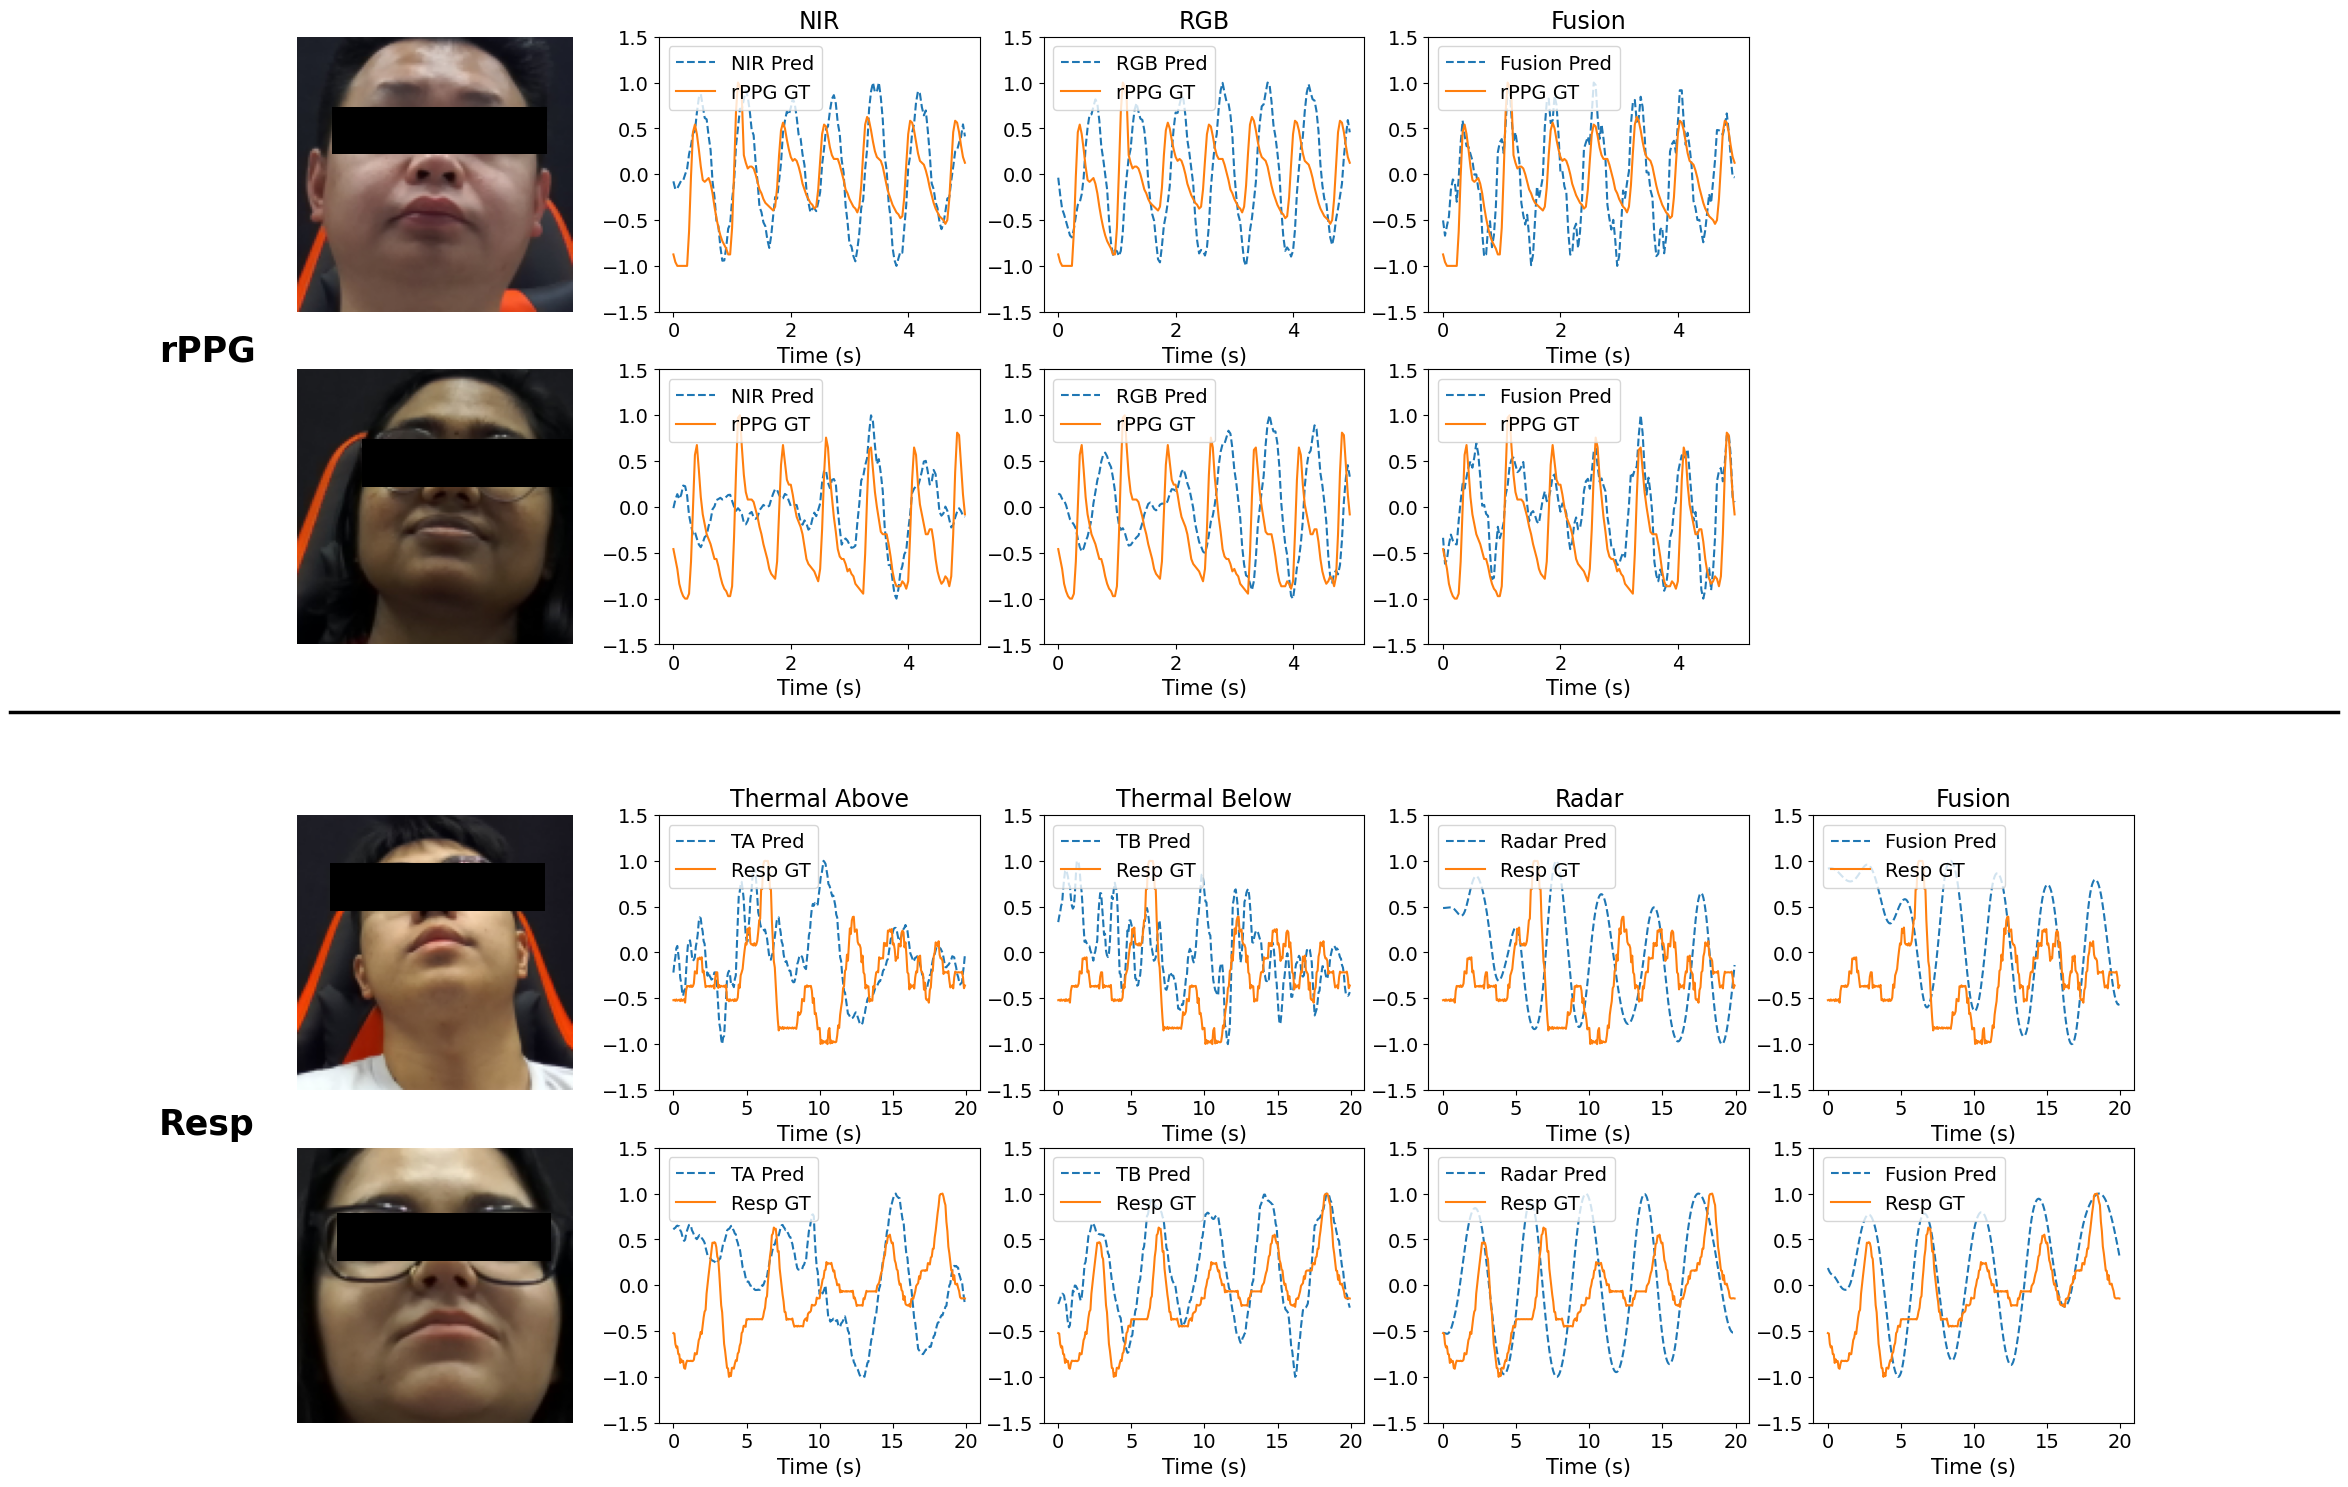

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def load_frame(participant, chunk_idx=0):
    frame_path = f'/shared/ab227/CogPhys/chunked_dataset/{participant}/rgb_left_0.npy'
    array = np.load(frame_path)
    return array[0]

def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')

def standardize(signal):
    min_val = np.min(signal)
    max_val = np.max(signal)
    if max_val - min_val == 0:
        return np.zeros_like(signal)
    return 2 * (signal - min_val) / (max_val - min_val) - 1

# Sampling rates
fs_rppg = 30
fs_resp = 15

# Load waveform data
fusion_rppg_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/fusion_pre_nir/pred.pickle')
rgb_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/rgb_cp+/pred.pickle')
nir_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/nir_cp+_pre/pred.pickle')
fusion_resp_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/wave_fusion/pred.pickle')
ta_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/ta_cp+/pred.pickle')
tb_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/tb_cp+/pred.pickle')
radar_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/test_radar_all/pred.pickle')

# Subjects
rppg_subjects = [('v22_pattern', [0, 1, 2]), ('v37_read_rest', [0, 1, 2])]
resp_subjects = [(98,101), (12,33)]
resp_participants = ['v11_pattern_rest', 'v38_still']

# Create figure
fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(5, 5, width_ratios=[1, 1, 1, 1, 1], height_ratios=[1, 1, 0.2, 1, 1], wspace=0.2, hspace=0.25)

axes = np.empty((5, 5), dtype=object)
for row in range(5):
    for col in range(5):
        if row != 2:  # Skip spacing row
            axes[row, col] = fig.add_subplot(gs[row, col])

# Plot RPPG
for row, (participant, chunk_ids) in enumerate(rppg_subjects):
    key = (participant, chunk_ids)
    try:
        idx = fusion_rppg_data['participant_task_chunk_id_list'].index(key)
    except ValueError:
        continue

    frame = load_frame(participant, chunk_ids[0])
    axes[row, 0].imshow(frame)
    axes[row, 0].axis('off')
    eye_bar = Rectangle((16 if row == 0 else 30, 32), 100, 22, facecolor='black')
    axes[row, 0].add_patch(eye_bar)

    # NIR
    pred = standardize(smooth_signal(nir_data['pred'][idx][:150]))
    gt = standardize(nir_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    axes[row, 1].plot(t, pred, '--', label='NIR Pred')
    axes[row, 1].plot(t, gt, label='rPPG GT')
    if row == 0: axes[row, 1].set_title("NIR")
    axes[row, 1].legend(loc='upper left')
    axes[row, 1].set_ylim(-1.5, 1.5)
    axes[row, 1].set_xlabel("Time (s)")

    # RGB
    pred = standardize(smooth_signal(rgb_data['pred'][idx][:150]))
    gt = standardize(rgb_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    axes[row, 2].plot(t, pred, '--', label='RGB Pred')
    axes[row, 2].plot(t, gt, label='rPPG GT')
    if row == 0: axes[row, 2].set_title("RGB")
    axes[row, 2].legend(loc='upper left')
    axes[row, 2].set_ylim(-1.5, 1.5)
    axes[row, 2].set_xlabel("Time (s)")

    # Fusion
    pred = standardize(smooth_signal(fusion_rppg_data['pred'][idx][:150]))
    gt = standardize(fusion_rppg_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    axes[row, 3].plot(t, pred, '--', label='Fusion Pred')
    axes[row, 3].plot(t, gt, label='rPPG GT')
    if row == 0: axes[row, 3].set_title("Fusion")
    axes[row, 3].legend(loc='upper left')
    axes[row, 3].set_ylim(-1.5, 1.5)
    axes[row, 3].set_xlabel("Time (s)")

    axes[row, 4].axis('off')  # No plot here

# Plot Respiration
for i, (ta_tb_radar_idx, fusion_idx) in enumerate(resp_subjects):
    row = i + 3
    frame = load_frame(resp_participants[i])
    axes[row, 0].imshow(frame)
    axes[row, 0].axis('off')
    eye_bar = Rectangle((15 if i == 0 else 18, 22 if i == 0 else 30), 100, 22, facecolor='black')
    axes[row, 0].add_patch(eye_bar)

    # TA
    pred = standardize(ta_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(ta_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 1].plot(t, pred, '--', label='TA Pred')
    axes[row, 1].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 1].set_title("Thermal Above")
    axes[row, 1].legend(loc='upper left')
    axes[row, 1].set_ylim(-1.5, 1.5)
    axes[row, 1].set_xlabel("Time (s)")

    # TB
    pred = standardize(tb_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(tb_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 2].plot(t, pred, '--', label='TB Pred')
    axes[row, 2].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 2].set_title("Thermal Below")
    axes[row, 2].legend(loc='upper left')
    axes[row, 2].set_ylim(-1.5, 1.5)
    axes[row, 2].set_xlabel("Time (s)")

    # Radar
    pred = standardize(radar_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(radar_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 3].plot(t, pred, '--', label='Radar Pred')
    axes[row, 3].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 3].set_title("Radar")
    axes[row, 3].legend(loc='upper left')
    axes[row, 3].set_ylim(-1.5, 1.5)
    axes[row, 3].set_xlabel("Time (s)")

    # Fusion
    pred = standardize(fusion_resp_data['pred'][fusion_idx][:300])
    gt = standardize(fusion_resp_data['gt'][fusion_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 4].plot(t, pred, '--', label='Fusion Pred')
    axes[row, 4].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 4].set_title("Fusion")
    axes[row, 4].legend(loc='upper left')
    axes[row, 4].set_ylim(-1.5, 1.5)
    axes[row, 4].set_xlabel("Time (s)")

# Bold horizontal separator
line = plt.Line2D([0.015, 0.985], [0.505, 0.505], transform=fig.transFigure, color='black', linewidth=2.5)
fig.add_artist(line)

# Section Labels
fig.text(0.077, 0.7, 'rPPG', fontsize=25, fontweight='bold')
fig.text(0.077, 0.27, 'Resp', fontsize=25, fontweight='bold')

plt.tight_layout()
plt.show()


/tmp/ipykernel_612473/146248666.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


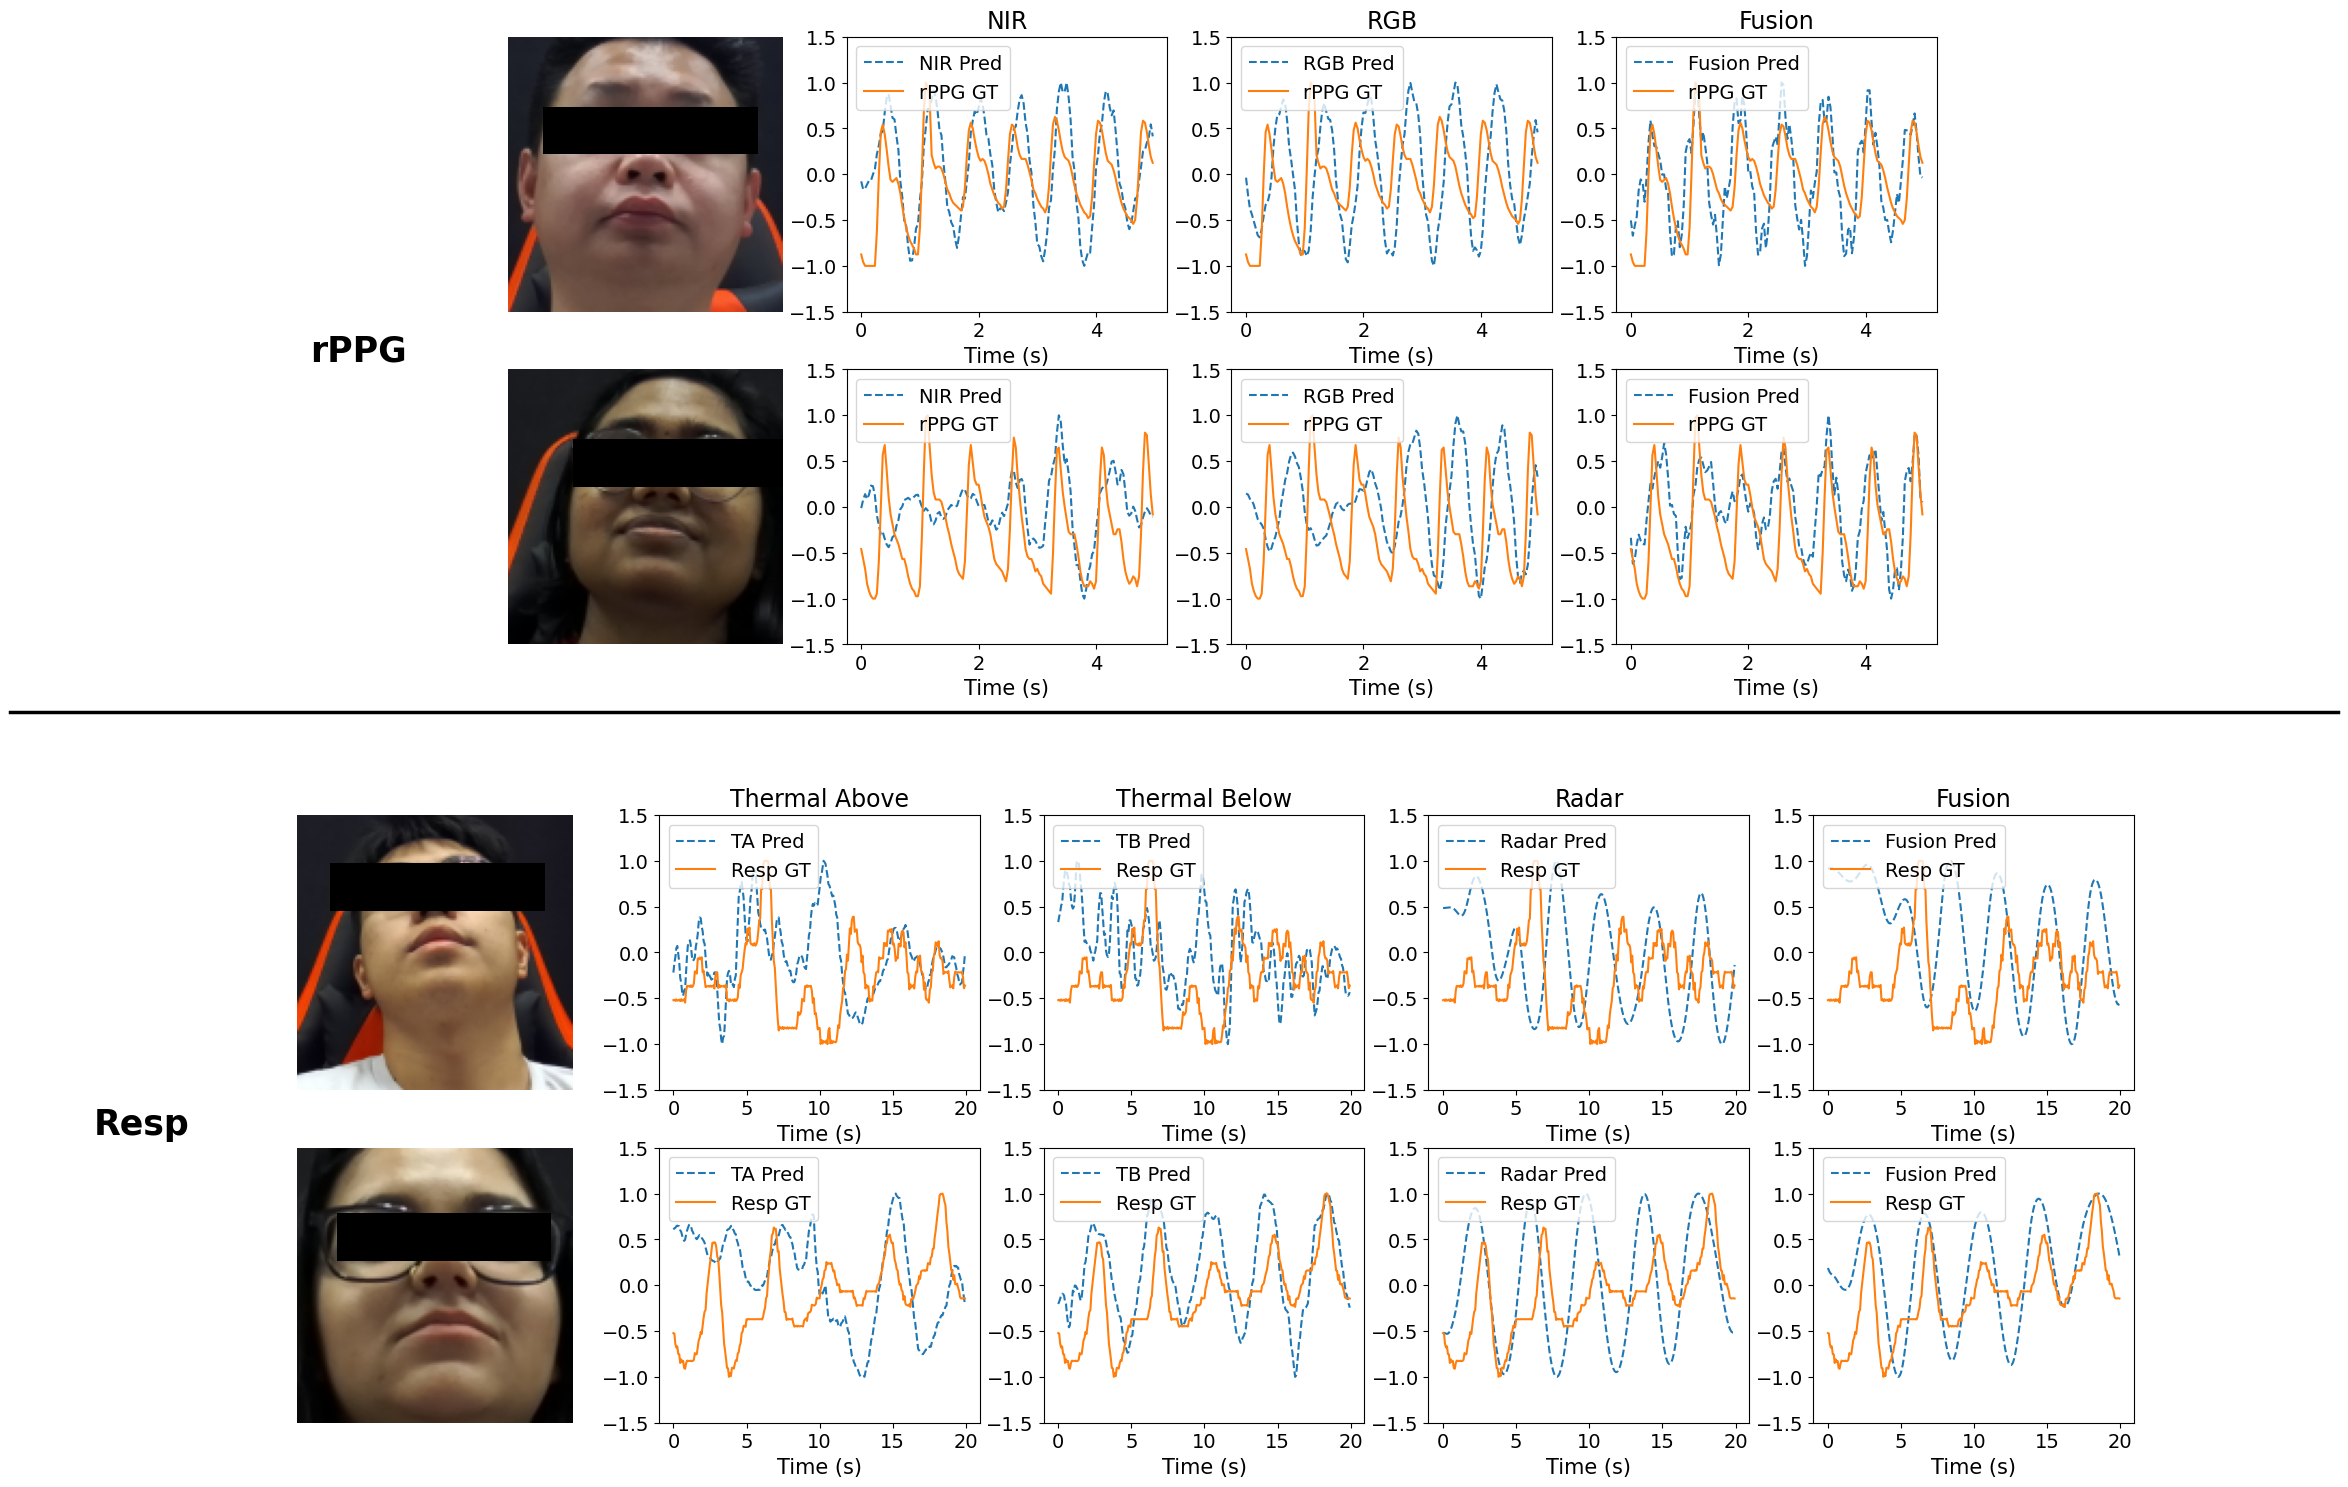

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def load_frame(participant, chunk_idx=0):
    frame_path = f'/shared/ab227/CogPhys/chunked_dataset/{participant}/rgb_left_0.npy'
    array = np.load(frame_path)
    return array[0]

def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')

def standardize(signal):
    min_val = np.min(signal)
    max_val = np.max(signal)
    if max_val - min_val == 0:
        return np.zeros_like(signal)
    return 2 * (signal - min_val) / (max_val - min_val) - 1

# Sampling rates
fs_rppg = 30
fs_resp = 15

# Load waveform data
fusion_rppg_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/fusion_pre_nir/pred.pickle')
rgb_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/rgb_cp+/pred.pickle')
nir_data = load_pickle('/home/dg73/CogPhys/waveforms/rppg/nir_cp+_pre/pred.pickle')
fusion_resp_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/wave_fusion/pred.pickle')
ta_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/ta_cp+/pred.pickle')
tb_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/tb_cp+/pred.pickle')
radar_data = load_pickle('/home/dg73/CogPhys/waveforms/resp/test_radar_all/pred.pickle')

# Subjects
rppg_subjects = [('v22_pattern', [0, 1, 2]), ('v37_read_rest', [0, 1, 2])]
resp_subjects = [(98,101), (12,33)]
resp_participants = ['v11_pattern_rest', 'v38_still']

# Create figure
fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(5, 5, width_ratios=[1, 1, 1, 1, 1], height_ratios=[1, 1, 0.2, 1, 1], wspace=0.2, hspace=0.25)

axes = np.empty((5, 5), dtype=object)
for row in range(5):
    for col in range(5):
        if row != 2:
            axes[row, col] = fig.add_subplot(gs[row, col])

# Plot RPPG (center-align top rows)
for row, (participant, chunk_ids) in enumerate(rppg_subjects):
    key = (participant, chunk_ids)
    try:
        idx = fusion_rppg_data['participant_task_chunk_id_list'].index(key)
    except ValueError:
        continue
    
    #hide 0th col axis
    hidden_ax = axes[row, 0]
    hidden_ax.axis('off')

    # Image
    frame = load_frame(participant, chunk_ids[0])
    ax_img = axes[row, 1]
    ax_img.imshow(frame)
    ax_img.axis('off')  # <- Hide axes
    eye_bar = Rectangle((16 if row == 0 else 30, 32), 100, 22, facecolor='black')
    ax_img.add_patch(eye_bar)

    # NIR
    pred = standardize(smooth_signal(nir_data['pred'][idx][:150]))
    gt = standardize(nir_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    ax_nir = axes[row, 2]
    ax_nir.plot(t, pred, '--', label='NIR Pred')
    ax_nir.plot(t, gt, label='rPPG GT')
    if row == 0: ax_nir.set_title("NIR")
    ax_nir.legend(loc='upper left')
    ax_nir.set_ylim(-1.5, 1.5)
    ax_nir.set_xlabel("Time (s)")

    # RGB
    pred = standardize(smooth_signal(rgb_data['pred'][idx][:150]))
    gt = standardize(rgb_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    ax_rgb = axes[row, 3]
    ax_rgb.plot(t, pred, '--', label='RGB Pred')
    ax_rgb.plot(t, gt, label='rPPG GT')
    if row == 0: ax_rgb.set_title("RGB")
    ax_rgb.legend(loc='upper left')
    ax_rgb.set_ylim(-1.5, 1.5)
    ax_rgb.set_xlabel("Time (s)")

    # Fusion
    pred = standardize(smooth_signal(fusion_rppg_data['pred'][idx][:150]))
    gt = standardize(fusion_rppg_data['gt'][idx][:150])
    t = np.arange(len(pred)) / fs_rppg
    ax_fusion = axes[row, 4]
    ax_fusion.plot(t, pred, '--', label='Fusion Pred')
    ax_fusion.plot(t, gt, label='rPPG GT')
    if row == 0: ax_fusion.set_title("Fusion")
    ax_fusion.legend(loc='upper left')
    ax_fusion.set_ylim(-1.5, 1.5)
    ax_fusion.set_xlabel("Time (s)")

    
    # Shift top row axes leftward by 0.5 column width + 0.5 wspace
    for col in range(1, 5):
        orig_pos = axes[row, col].get_position()
        shift = (orig_pos.x1 - orig_pos.x0 + gs.get_subplot_params(fig).wspace * orig_pos.height) / 2
        axes[row, col].set_position([
            orig_pos.x0 - shift,
            orig_pos.y0,
            orig_pos.width,
            orig_pos.height
        ])
        

# Plot Respiration
for i, (ta_tb_radar_idx, fusion_idx) in enumerate(resp_subjects):
    row = i + 3
    frame = load_frame(resp_participants[i])
    axes[row, 0].imshow(frame)
    axes[row, 0].axis('off')
    eye_bar = Rectangle((15 if i == 0 else 18, 22 if i == 0 else 30), 100, 22, facecolor='black')
    axes[row, 0].add_patch(eye_bar)

    # TA
    pred = standardize(ta_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(ta_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 1].plot(t, pred, '--', label='TA Pred')
    axes[row, 1].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 1].set_title("Thermal Above")
    axes[row, 1].legend(loc='upper left')
    axes[row, 1].set_ylim(-1.5, 1.5)
    axes[row, 1].set_xlabel("Time (s)")

    # TB
    pred = standardize(tb_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(tb_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 2].plot(t, pred, '--', label='TB Pred')
    axes[row, 2].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 2].set_title("Thermal Below")
    axes[row, 2].legend(loc='upper left')
    axes[row, 2].set_ylim(-1.5, 1.5)
    axes[row, 2].set_xlabel("Time (s)")

    # Radar
    pred = standardize(radar_data['pred'][ta_tb_radar_idx][:300])
    gt = standardize(radar_data['gt'][ta_tb_radar_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 3].plot(t, pred, '--', label='Radar Pred')
    axes[row, 3].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 3].set_title("Radar")
    axes[row, 3].legend(loc='upper left')
    axes[row, 3].set_ylim(-1.5, 1.5)
    axes[row, 3].set_xlabel("Time (s)")

    # Fusion
    pred = standardize(fusion_resp_data['pred'][fusion_idx][:300])
    gt = standardize(fusion_resp_data['gt'][fusion_idx][:300])
    t = np.arange(len(pred)) / fs_resp
    axes[row, 4].plot(t, pred, '--', label='Fusion Pred')
    axes[row, 4].plot(t, gt, label='Resp GT')
    if i == 0: axes[row, 4].set_title("Fusion")
    axes[row, 4].legend(loc='upper left')
    axes[row, 4].set_ylim(-1.5, 1.5)
    axes[row, 4].set_xlabel("Time (s)")

# Separator line
line = plt.Line2D([0.015, 0.985], [0.505, 0.505], transform=fig.transFigure, color='black', linewidth=2.5)
fig.add_artist(line)

# Section Labels
fig.text(0.14, 0.7, 'rPPG', fontsize=25, fontweight='bold')
fig.text(0.05, 0.27, 'Resp', fontsize=25, fontweight='bold')

plt.tight_layout()
plt.show()
